# Jake Wright Kaggle — 9k+ stock data quick look

Source: `jakewright_kaggle_all_stock_data.parquet` (~35M rows, Date / Ticker / OHLCV / Dividends / Stock Splits)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

PATH = "jakewright_kaggle_all_stock_data.parquet"
df = pd.read_parquet(PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1962-01-02,ED,0.0,0.265828,0.261788,0.261788,25600.0,0.0,0.0
1,1962-01-02,CVX,0.0,0.046809,0.046069,0.046809,105840.0,0.0,0.0
2,1962-01-02,GD,0.0,0.210033,0.203061,0.208290,2648000.0,0.0,0.0
3,1962-01-02,BP,0.0,0.141439,0.139528,0.139528,77440.0,0.0,0.0
4,1962-01-02,MSI,0.0,0.764923,0.745254,0.751810,65671.0,0.0,0.0


## Schema

In [14]:
display(df.dtypes.to_frame("dtype"))
print(f"rows={len(df):,}  cols={list(df.columns)}")
print(f"date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"tickers: {df['Ticker'].nunique():,}")
df.describe()

,dtype
Date,datetime64[s]
Ticker,str
Open,float64
High,float64
Low,float64
Close,float64
Volume,float64
Dividends,float64
Stock Splits,float64


rows=34,646,258  cols=['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']
date range: 1962-01-02 → 2024-11-04
tickers: 9,315


c:\Users\Peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,34646258,3.464615e+07,3.464615e+07,3.464615e+07,3.464615e+07,3.464626e+07,3.464626e+07,34646258.0
mean,2011-07-18 04:32:44,1.115049e+23,1.115049e+23,1.115049e+23,1.115049e+23,1.339230e+06,3.980156e-03,inf
min,1962-01-02 00:00:00,-8.210044e+25,-8.210044e+25,-8.210044e+25,-8.210044e+25,0.000000e+00,0.000000e+00,0.0
25%,2005-02-17 00:00:00,3.150000e+00,3.400000e+00,3.262533e+00,3.331568e+00,2.680000e+03,0.000000e+00,0.0
50%,2014-07-02 00:00:00,1.088000e+01,1.112991e+01,1.082000e+01,1.098039e+01,5.380000e+04,0.000000e+00,0.0
75%,2020-08-25 00:00:00,2.802786e+01,2.867335e+01,2.779270e+01,2.822554e+01,4.270000e+05,0.000000e+00,0.0
max,2024-11-04 00:00:00,1.507290e+28,1.507290e+28,1.507290e+28,1.507290e+28,9.230856e+09,4.500000e+03,inf
std,NaN,3.954735e+25,3.954735e+25,3.954735e+25,3.954735e+25,1.567170e+07,1.603516e+00,NaN


## Granularity

In [19]:
# Expected: daily bars, one row per (Ticker, Date)

dup_keys = df.duplicated(subset=["Ticker", "Date"]).sum()
n_pairs = df[["Ticker", "Date"]].drop_duplicates().shape[0]
print(f"rows={len(df):,}  unique (Ticker, Date)={n_pairs:,}  duplicate keys={dup_keys:,}")
print(f"Date dtype: {df['Date'].dtype}")
print(f"any non-midnight time: {(df['Date'].dt.normalize() != df['Date']).any()}")

sample_tickers = df.groupby("Ticker").size().nlargest(200).index
g = df.loc[df["Ticker"].isin(sample_tickers), ["Ticker", "Date"]].sort_values(["Ticker", "Date"])
gaps = g.groupby("Ticker")["Date"].diff().dt.days.dropna()
print("\ngap days between consecutive bars (top-200 tickers by length):")
display(gaps.value_counts().head(15).to_frame("count"))

print("\nrows by weekday (0=Mon … 6=Sun):")
display(df["Date"].dt.dayofweek.value_counts().sort_index().to_frame("rows"))


rows=34,646,258  unique (Ticker, Date)=34,646,258  duplicate keys=0
Date dtype: datetime64[s]
any non-midnight time: False

gap days between consecutive bars (top-200 tickers by length):


,count
Date,
1.0,2090369
3.0,487364
4.0,65188
2.0,27199
5.0,643
7.0,248
6.0,99
8.0,19
9.0,11



rows by weekday (0=Mon … 6=Sun):


,rows
Date,
0,6494003
1,7107781
2,7107299
3,6989932
4,6947243


## Universe coverage

,rows,first,last,span_days
Ticker,,,,
PG,15819,1962-01-02,2024-11-04,22952
IP,15819,1962-01-02,2024-11-04,22952
JNJ,15819,1962-01-02,2024-11-04,22952
BA,15819,1962-01-02,2024-11-04,22952
KO,15819,1962-01-02,2024-11-04,22952
AEP,15819,1962-01-02,2024-11-04,22952
CVX,15819,1962-01-02,2024-11-04,22952
ED,15819,1962-01-02,2024-11-04,22952
CAT,15819,1962-01-02,2024-11-04,22952


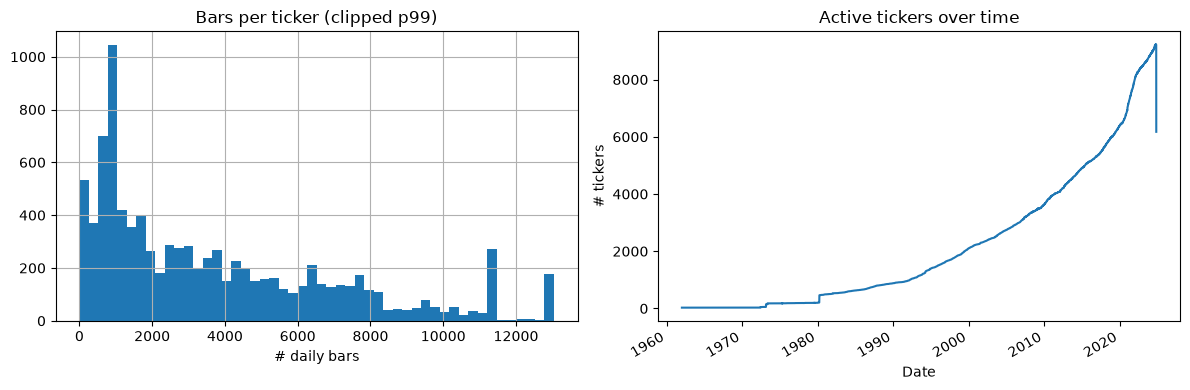

In [15]:
per_ticker = (
    df.groupby("Ticker", observed=True)
    .agg(rows=("Date", "size"), first=("Date", "min"), last=("Date", "max"))
    .assign(span_days=lambda x: (x["last"] - x["first"]).dt.days)
    .sort_values("rows", ascending=False)
)
display(per_ticker.head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_ticker["rows"].clip(upper=per_ticker["rows"].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title("Bars per ticker (clipped p99)")
axes[0].set_xlabel("# daily bars")

active = df.groupby("Date")["Ticker"].nunique()
active.plot(ax=axes[1])
axes[1].set_title("Active tickers over time")
axes[1].set_ylabel("# tickers")
plt.tight_layout()
plt.show()

## Unique tickers by year

unique tickers: 9,315


year,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
n_tickers,30,30,30,30,31,31,31,31,31,31,...,5144,5334,5659,6015,6401,6927,8033,8484,8861,9311
n_records,7497,7530,7590,7560,7685,7781,7006,7750,7874,7843,...,1267156,1316689,1374638,1466976,1559858,1669620,1892499,2081575,2161042,1922093


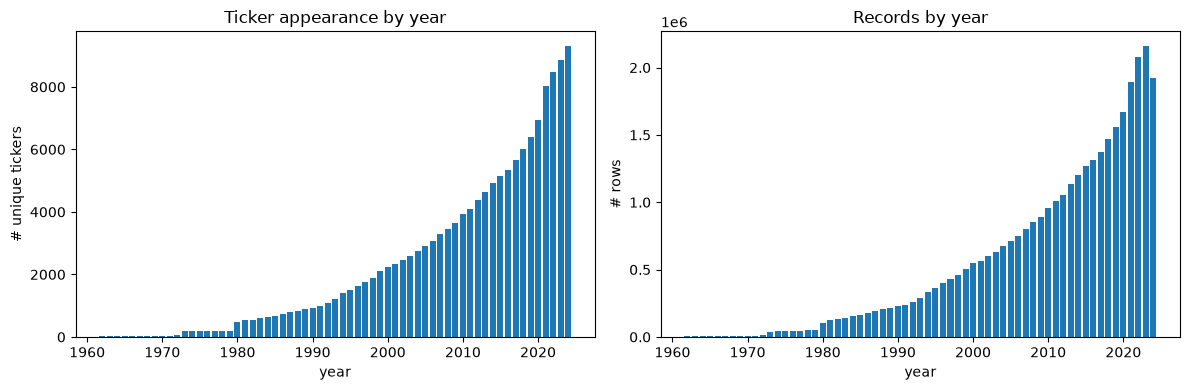

In [16]:
n_tickers = df["Ticker"].nunique()
print(f"unique tickers: {n_tickers:,}")

by_year = (
    df.assign(year=df["Date"].dt.year)
    .groupby("year")
    .agg(n_tickers=("Ticker", "nunique"), n_records=("Ticker", "size"))
)
display(by_year.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_year.index, by_year["n_tickers"], width=0.8)
axes[0].set_title("Ticker appearance by year")
axes[0].set_ylabel("# unique tickers")
axes[0].set_xlabel("year")

axes[1].bar(by_year.index, by_year["n_records"], width=0.8)
axes[1].set_title("Records by year")
axes[1].set_ylabel("# rows")
axes[1].set_xlabel("year")
plt.tight_layout()
plt.show()


## Sample prices

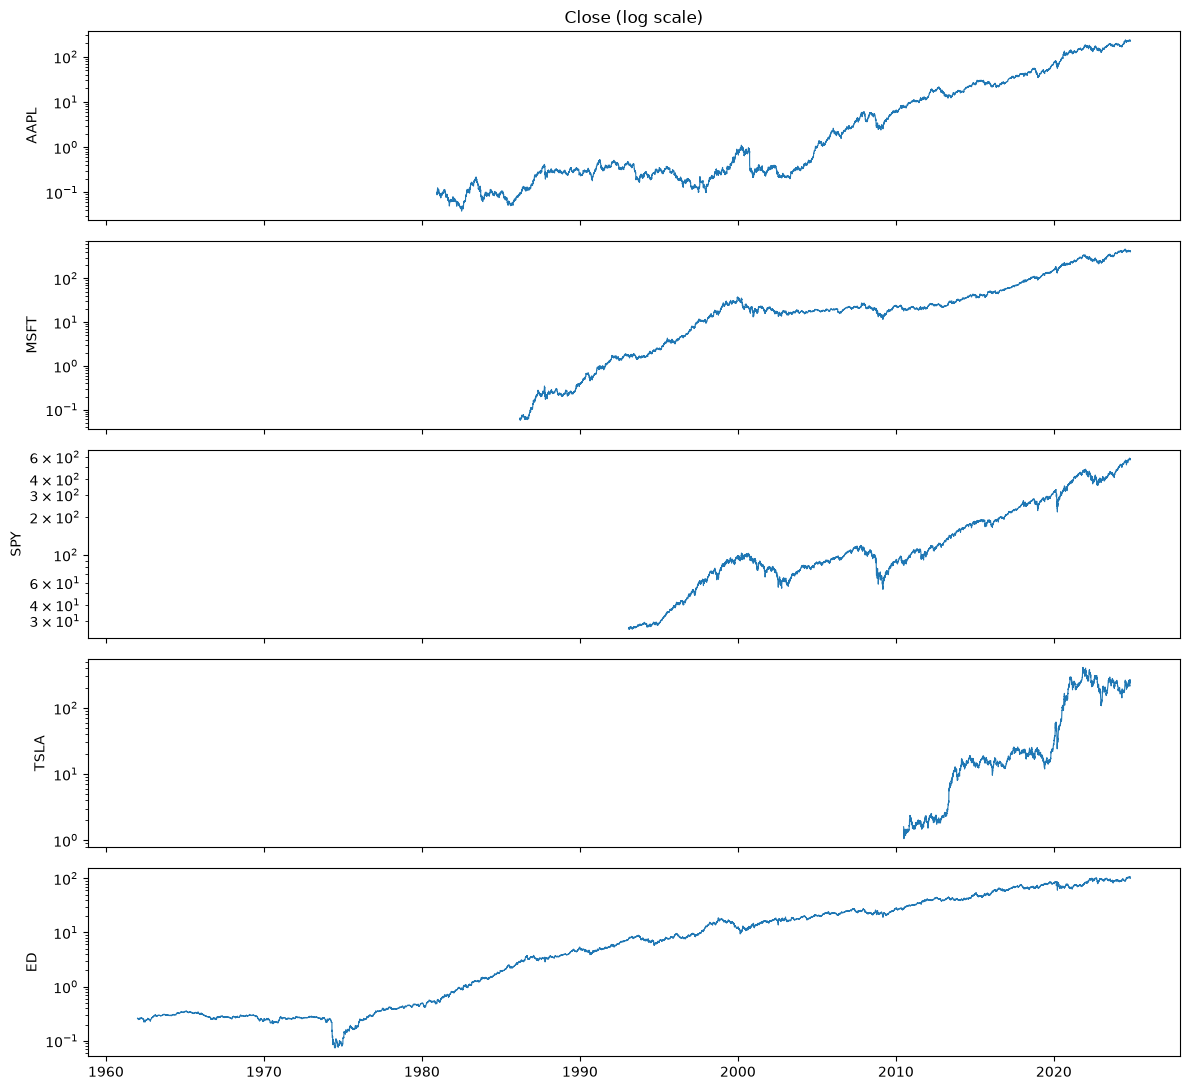

,first_date,last_date,bars,last_close
Ticker,,,,
AAPL,1980-12-12,2024-11-04,11066,220.779999
ED,1962-01-02,2024-11-04,15819,99.830002
MSFT,1986-03-13,2024-11-04,9740,408.299988
SPY,1993-01-29,2024-11-04,7999,570.479980
TSLA,2010-06-29,2024-11-04,3613,240.539993


In [17]:
SAMPLES = ["AAPL", "MSFT", "SPY", "TSLA", "ED"]
sample = df[df["Ticker"].isin(SAMPLES)].sort_values(["Ticker", "Date"])

fig, axes = plt.subplots(len(SAMPLES), 1, figsize=(12, 2.2 * len(SAMPLES)), sharex=True)
for ax, t in zip(axes, SAMPLES):
    s = sample[sample["Ticker"] == t]
    ax.plot(s["Date"], s["Close"], lw=0.8)
    ax.set_ylabel(t)
    ax.set_yscale("log")
axes[0].set_title("Close (log scale)")
plt.tight_layout()
plt.show()

sample.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    bars=("Date", "size"),
    last_close=("Close", "last"),
)

## Dividends / splits + volume sanity

dividend events: 241,706  |  split events: 7,726


,Date,Ticker,Dividends,Close
14790656,2012-03-28,OSCUF,4500.0,3.583930e+03
15318041,2012-09-26,OSCUF,4500.0,-8.688948e+02
15318621,2012-09-26,NTTDF,3000.0,-6.615440e-03
15856182,2013-03-27,NTTDF,3000.0,7.894560e-05
6490405,2001-09-10,VHI,1000.0,-6.211265e+02
8547137,2004-12-20,TOPS,1000.0,8.618400e+14
8733293,2005-03-29,TOPS,1000.0,8.006040e+14
8922066,2005-07-05,TOPS,1000.0,7.139664e+14
8940392,2005-07-13,TOPS,1000.0,7.470792e+14
9121400,2005-10-12,TOPS,1000.0,6.422976e+14


,Date,Ticker,Stock Splits,Close
4549284,1997-12-04,SBR,inf,1.591287
5783719,2000-06-08,SBR,inf,2.622788
16575766,2013-11-11,WES,inf,23.582815
8571229,2005-01-03,USAS,1000.0,10.800000
17049642,2014-04-10,ALLY,310.0,21.107729
16704215,2013-12-20,GEG,200.0,17.160000
16613796,2013-11-22,AKR,156.0,19.565693
7003269,2002-07-30,ARE,100.0,22.792749
15583079,2012-12-26,OSCUF,100.0,-1053.211792
25152693,2020-02-25,AGTX,100.0,24.000000


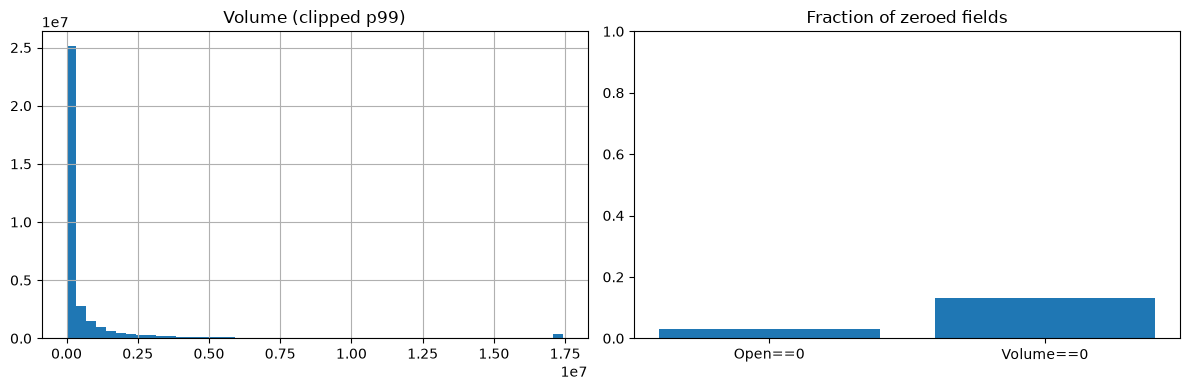

In [18]:
divs = df[df["Dividends"] > 0]
splits = df[df["Stock Splits"] != 0]
print(f"dividend events: {len(divs):,}  |  split events: {len(splits):,}")
display(divs.nlargest(10, "Dividends")[["Date", "Ticker", "Dividends", "Close"]])
display(splits.nlargest(10, "Stock Splits")[["Date", "Ticker", "Stock Splits", "Close"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Volume"].clip(upper=df["Volume"].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title("Volume (clipped p99)")

zero_open = (df["Open"] == 0).mean()
zero_vol = (df["Volume"] == 0).mean()
axes[1].bar(["Open==0", "Volume==0"], [zero_open, zero_vol])
axes[1].set_ylim(0, 1)
axes[1].set_title("Fraction of zeroed fields")
plt.tight_layout()
plt.show()